In [1]:
# Data visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Learning rate
from sklearn.linear_model import LinearRegression
import numpy as np

# Data saving
import pickle
import os
import csv

# Metadata time format
from datetime import datetime

import csv_edit_toolbox_bird as csv_tb


In [2]:
# ******* EDIT THE LABEL BELOW *******
labels = ['pilot1', 'r21run1', 'r21run2', 'r21run3', 'r21run4', 'r21run5', 'r21run6']

# Calculate the total score for each survey & add inattentive column per survey 


In [3]:
folder_path = '/Users/Kary/iCloud/Projects/bird_data/processed_all/'
os.chdir(folder_path)
output_folder = '../csv_edited/'

for lab in labels:
    df_surveys = pd.read_csv(lab + '_surveys.csv')
    df_surveys_edited = csv_tb.calculate_total_score(df_surveys)
    df_surveys_edited = csv_tb.add_inattentive_column(df_surveys_edited)
    # Save the edited csv file
    df_surveys_edited.to_csv(output_folder + lab + '_surveys_edited.csv', index=False)


Survey names:  ['ius12', 'pvp9', 'audit10', 'gbq21', 'gad7', 'pswq8', 'cape15', 'bis8', 'dass21', 'eat26', 'phq9', 'whodas12', 'lbt2', 'cbs7', 'yboc', 'dsm23']
['ius12_Q01', 'ius12_Q02', 'ius12_Q03', 'ius12_Q04', 'ius12_Q05', 'ius12_Q06', 'ius12_Q07', 'ius12_Q08', 'ius12_Q09', 'ius12_Q10', 'ius12_Q11', 'ius12_Q12']
12
['pvp9_Q01', 'pvp9_Q02', 'pvp9_Q03', 'pvp9_Q04', 'pvp9_Q05', 'pvp9_Q06', 'pvp9_Q07', 'pvp9_Q08', 'pvp9_Q09']
9
['audit10_Q01', 'audit10_Q02', 'audit10_Q03', 'audit10_Q04', 'audit10_Q05', 'audit10_Q06', 'audit10_Q07', 'audit10_Q08', 'audit10_Q09', 'audit10_Q10']
10
['gbq21_Q01', 'gbq21_Q02', 'gbq21_Q03', 'gbq21_Q04', 'gbq21_Q05', 'gbq21_Q06', 'gbq21_Q07', 'gbq21_Q08', 'gbq21_Q09', 'gbq21_Q10', 'gbq21_Q11', 'gbq21_Q12', 'gbq21_Q13', 'gbq21_Q14', 'gbq21_Q15', 'gbq21_Q16', 'gbq21_Q17', 'gbq21_Q18', 'gbq21_Q19', 'gbq21_Q20', 'gbq21_Q21']
21
['gad7_Q01', 'gad7_Q02', 'gad7_Q03', 'gad7_Q04', 'gad7_Q05', 'gad7_Q06', 'gad7_Q07']
7
['pswq8_Q01', 'pswq8_Q02', 'pswq8_Q03', 'pswq8_Q04'

# Metadata validation (match workerId and subId)

### Goals
- match 'workerId' with 'subId' (some participants may have multiple subId)
- extract 'interview_date' for NDA data submission

### Used files and folders
- from saved '_subID.pkl' extract subject Ids that have valid data (folderpath + processed/)
- from metadata folder match 'workerId' and extract date information (folderpath + metadata/)

### Outputs
- '_matched_data.csv' with headers ['workerId', 'subId', 'interview_date'] (folderpath + processed/)

In [4]:
# Import _surveys_edited.csv file
# set up the working directory
folder_path = "/Users/Kary/iCloud/Projects/bird_data/"
os.chdir(folder_path)

output_path = 'csv_edited/'
for lab in labels:
    df_surveys = pd.read_csv('csv_edited/' + lab + '_surveys_edited.csv')
    csv_tb.match_workerId_subId(df_surveys, lab, output_path)

Total number of metadata matched subjects (pilot1): 202
Total number of metadata matched subjects (r21run1): 422
Total number of metadata matched subjects (r21run2): 415
Total number of metadata matched subjects (r21run3): 414
Total number of metadata matched subjects (r21run4): 401
Total number of metadata matched subjects (r21run5): 416
Total number of metadata matched subjects (r21run6): 419



# Add the matched workerId and interview_date to the edited surveys and trials csv files


In [5]:
# set up the working directory
folder_path = "/Users/Kary/iCloud/Projects/bird_data/"
os.chdir(folder_path)
input_trial_folder = 'processed_all/'
input_demo_folder = 'demographic_summary/'
input_survey_folder = 'csv_edited/'
output_folder = 'csv_edited/'
for lab in labels:
    matched_Id = pd.read_csv(input_survey_folder + lab + '_matched_Id.csv')
    
    # CLEAN THE TRIALS DATA
    df_trials = pd.read_csv(input_trial_folder + lab + '_trials.csv')
    # Merge the cleaned_trials_all.csv file with the matched_Id.csv file
    df_trials = matched_Id.merge(df_trials, on='subId', how='left')
    df_trials.to_csv(output_folder + lab + '_cleaned_trials.csv', index=False)
    
    # CLEAN THE SURVEYS DATA
    df_surveys = pd.read_csv(input_survey_folder + lab + '_surveys_edited.csv')
    # Merge the _surveys_edited.csv file with the matched_Id.csv file
    df_surveys = matched_Id.merge(df_surveys, on='subId', how='left')
    df_surveys = csv_tb.clean_survey_time(df_surveys, df_trials)
    # Match the demographic data
    prolific_demo = pd.read_csv(input_demo_folder + lab + '_prolific_demographic.csv')
    df_surveys = csv_tb.fill_missing_demos(df_surveys, prolific_demo)
    df_surveys.to_csv(output_folder + lab + '_cleaned_surveys.csv', index=False)


## Merge the cleaned trials and surveys data


In [6]:
# set up the working directory
folder_path = "/Users/Kary/iCloud/Projects/bird_data/csv_edited/"
os.chdir(folder_path)

pilot1_surveys = pd.read_csv('pilot1_cleaned_surveys.csv')
pilot1_trials = pd.read_csv('pilot1_cleaned_trials.csv')
run1_surveys = pd.read_csv('r21run1_cleaned_surveys.csv')
run1_trials = pd.read_csv('r21run1_cleaned_trials.csv')
run2_surveys = pd.read_csv('r21run2_cleaned_surveys.csv')
run2_trials = pd.read_csv('r21run2_cleaned_trials.csv')
run3_surveys = pd.read_csv('r21run3_cleaned_surveys.csv')
run3_trials = pd.read_csv('r21run3_cleaned_trials.csv')
run4_surveys = pd.read_csv('r21run4_cleaned_surveys.csv')
run4_trials = pd.read_csv('r21run4_cleaned_trials.csv')
run5_surveys = pd.read_csv('r21run5_cleaned_surveys.csv')
run5_trials = pd.read_csv('r21run5_cleaned_trials.csv')
run6_surveys = pd.read_csv('r21run6_cleaned_surveys.csv')
run6_trials = pd.read_csv('r21run6_cleaned_trials.csv')

In [7]:
# add label column to the survey and trials data
pilot1_surveys['label'] = 'pilot1'
pilot1_trials['label'] = 'pilot1'
run1_surveys['label'] = 'run1'
run1_trials['label'] = 'run1'
run2_surveys['label'] = 'run2'
run2_trials['label'] = 'run2'
run3_surveys['label'] = 'run3'
run3_trials['label'] = 'run3'
run4_surveys['label'] = 'run4'
run4_trials['label'] = 'run4'
run5_surveys['label'] = 'run5'
run5_trials['label'] = 'run5'
run6_surveys['label'] = 'run6'
run6_trials['label'] = 'run6'


In [8]:
# merge the survey and trials data
df_surveys = pd.concat([pilot1_surveys, run1_surveys, run2_surveys, run3_surveys, run4_surveys, run5_surveys, run6_surveys])
df_trials = pd.concat([pilot1_trials, run1_trials, run2_trials, run3_trials, run4_trials, run5_trials, run6_trials])
df_surveys.to_csv('cleaned_surveys_all.csv', index=False)
df_trials.to_csv('cleaned_trials_all.csv', index=False)

In [9]:
# the size of df_surveys and df_trials
print(df_surveys.shape)
print(df_trials.shape)

(2689, 286)
(537800, 13)


In [11]:
df_surveys['demo_age_month'].value_counts()

demo_age_month
396.0     103
384.0      95
372.0      95
300.0      94
360.0      94
         ... 
1044.0      1
1008.0      1
936.0       1
1032.0      1
924.0       1
Name: count, Length: 65, dtype: int64

In [10]:
df_surveys['total_inattentive'].value_counts()


total_inattentive
0    2102
1     406
2     108
3      35
4      15
5      12
6       4
7       4
8       3
Name: count, dtype: int64

In [12]:
df_surveys['total_inattentive'].value_counts()


total_inattentive
0    1805
1     611
2     164
3      54
4      22
5      13
6       9
7       5
8       4
9       2
Name: count, dtype: int64

In [23]:
df_surveys['total_inattentive'].value_counts()


total_inattentive
0    2102
1     406
2     108
3      35
4      15
5      12
6       4
7       4
8       3
Name: count, dtype: int64

In [11]:
a = df_surveys.filter(like='command').sum(axis=1)
a.value_counts()


0    2163
1     476
2      45
3       5
Name: count, dtype: int64

In [11]:
# sum the columns with 'command' in the column name
a = df_surveys.filter(like='command').sum(axis=1)
a.value_counts()

0    2585
1      97
2       7
Name: count, dtype: int64

In [28]:
# sum the columns with 'command' in the column name
a = df_surveys.filter(like='command').sum(axis=1)
a.value_counts()

0    2585
1      97
2       7
Name: count, dtype: int64

In [11]:
df_surveys[(df_surveys['total_inattentive']>2) | (a>=1)]


,workerId,subId,interview_date,gad7_Q01,gad7_Q02,gad7_Q03,gad7_Q04,gad7_Q05,gad7_Q06,gad7_Q07,...,demo_weight,demo_ethnicity,demo_race,demo_language,demo_fluency,demo_time_elapsed,demo_employment_status,demo_age_month,demo_sex,label
9,5f5d25e5b17ec4562931508f,ye5rc86478a9aqpx0papb5ed,03/08/2024,1,1,2,1,2,2,1,...,200.0,Not Hispanic or Latino,White,Yes,Very well,7.54,DATA_EXPIRED,3.600000e+02,F,pilot1
53,5dd38420a71de83809342ca3,tuyblj7a8gneb1rdfhht0aw0,03/08/2024,0,0,0,0,0,0,0,...,200.0,Not Hispanic or Latino,White,Yes,Very well,2.84,Full-Time,6.360000e+02,M,pilot1
83,5bef64b373e44f0001092811,1bfu70onkum4dic2nfoadsik,03/08/2024,1,1,1,1,1,1,1,...,125.0,Not Hispanic or Latino,White,Yes,Very well,1.11,Full-Time,3.720000e+02,F,pilot1
87,6533da3b8ba3fc333c6e28e1,8f1i1irh19ltyw5lkp3tcc7r,03/08/2024,1,1,1,0,1,0,0,...,130.0,Not Hispanic or Latino,White,Yes,Very well,3.12,Part-Time,6.000000e+02,M,pilot1
97,6406d015ad2a96ceef1f86cc,n41y03jj69gxrepoepqlgzj8,03/08/2024,0,0,0,0,0,0,0,...,180.0,Not Hispanic or Latino,White,Yes,Very well,1.74,DATA_EXPIRED,8.760000e+02,M,pilot1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,661565a9e2816f002d25ea56,lmkx2432hzwz275s0p9zma8o,04/22/2024,0,0,0,0,0,0,0,...,210.0,Not Hispanic or Latino,White,Yes,Very well,2.37,Full-Time,3.000000e+02,M,run6
369,62dd9de432522cb0157febc9,hnbtgpri2m4sdjght5bpmc9c,04/24/2024,0,0,0,0,0,0,0,...,145.0,Hispanic or Latino,Other,No,Very well,1.21,Unemployed (and job seeking),3.360000e+02,M,run6
389,65b66b24e8ccc2285f3dd219,obpvk9i0q5f3pw43bg7g4kp9,04/23/2024,0,0,0,0,0,0,0,...,NaN,NaN,Black,NaN,NaN,NaN,DATA_EXPIRED,5.151515e+23,M,run6
392,6096d9b30d92183ab4f552a3,yqdenrpi9w8cd6j3yrrns7fz,04/22/2024,1,1,0,0,0,0,0,...,175.0,Hispanic or Latino,Black or African American,Yes,Very well,3.44,Full-Time,3.000000e+02,M,run6


In [30]:
print(df_surveys['workerId'].nunique())
print(df_trials['workerId'].nunique())
# count the number of each label
print(df_surveys['label'].value_counts())
print(df_trials['label'].value_counts()/200)

2689
2689
label
run1      422
run6      419
run5      416
run2      415
run3      414
run4      401
pilot1    202
Name: count, dtype: int64
label
run1      422.0
run6      419.0
run5      416.0
run2      415.0
run3      414.0
run4      401.0
pilot1    202.0
Name: count, dtype: float64


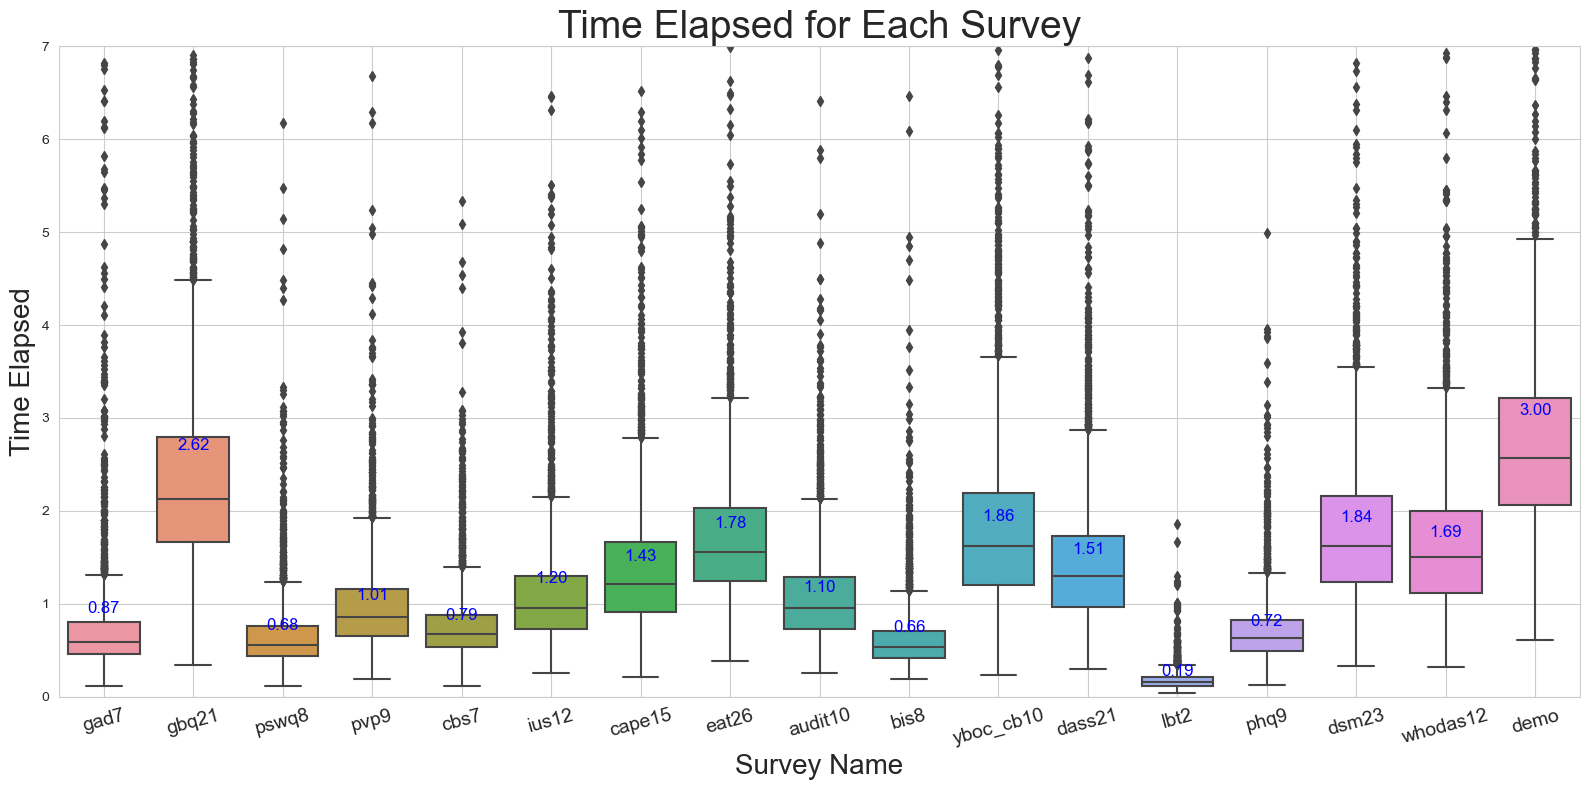

In [17]:
csv_tb.survey_time_plot(df_surveys)

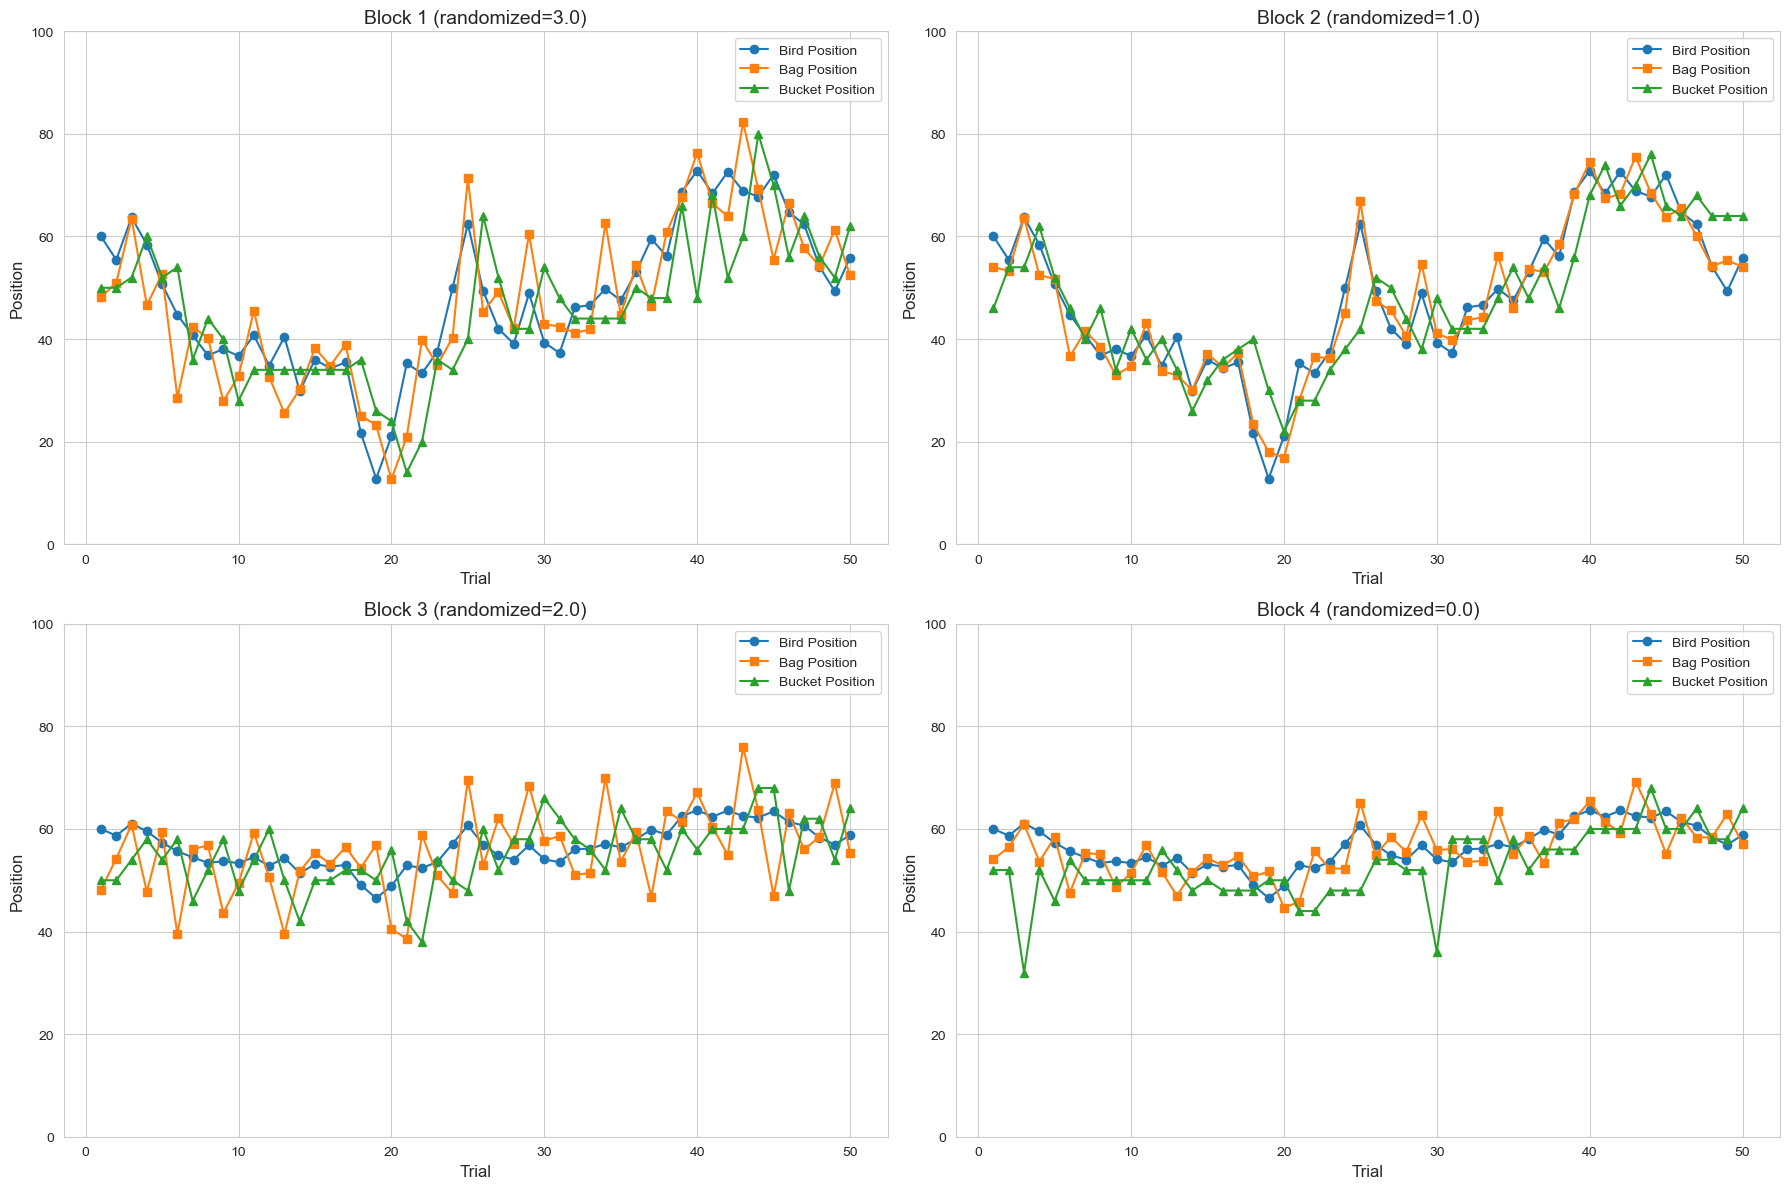

In [16]:
csv_tb.trials_plot(df_trials)